In [1]:
import numpy as np
from tqdm import tqdm
from trace_IO import *

def deepest_valley_idx(chisq: np.ndarray, win: int = 4097) -> int:
    """
    Return index of the dominant local minimum ("big drop") in chisq.
    Uses a wide moving-average baseline via cumulative sums (fast, no SciPy).

    win: baseline window (must be odd). Choose >> dip width (e.g., 2049–8193).
    """
    y = np.asarray(chisq, dtype=float)
    win = int(win) | 1  # force odd

    # moving average via cumulative sum (valid region)
    c = np.cumsum(np.insert(y, 0, 0.0))
    ma_valid = (c[win:] - c[:-win]) / win

    # pad to 'same' length by extending edges
    pad = win // 2
    baseline = np.pad(ma_valid, (pad, pad), mode='edge')

    drop = baseline - y
    return int(np.argmax(drop))


# Parameters
energy_values = list(range(0, 96, 5))  # e.g., 0, 5, 10, ..., 95
n_sets = 100
n_channels = 9
n_samples = 250000

# Output array: shape (n_energies, n_sets, n_channels)
all_amplitudes = np.empty((len(energy_values), n_sets, n_channels), dtype=float)

for e_idx, energy in enumerate(energy_values):
    print(f"Processing energy {energy} eV...")
    
    # Load chisq and amplitude traces (shape: 100, 9, 250000)
    chisq_arr = load_ampl_from_zstd(f"/ceph/dwong/trigger_samples/lts_stft/chisq_energy_{energy}.zst",
                                    n_traces=n_sets)
    ampl_arr  = load_ampl_from_zstd(f"/ceph/dwong/trigger_samples/lts_stft/ampl_energy_{energy}.zst",
                                    n_traces=n_sets)

    # Loop over events and channels
    for evt_idx in range(n_sets):
        for ch_idx in range(n_channels):
            valley_i = deepest_valley_idx(chisq_arr[evt_idx, ch_idx, :], win=4097)
            all_amplitudes[e_idx, evt_idx, ch_idx] = ampl_arr[evt_idx, ch_idx, valley_i]

print("Done. Result array shape:", all_amplitudes.shape)
# all_amplitudes[e_idx] → (100, 9) amplitudes for that energy


Processing energy 0 eV...
Processing energy 5 eV...
Processing energy 10 eV...
Processing energy 15 eV...
Processing energy 20 eV...
Processing energy 25 eV...
Processing energy 30 eV...
Processing energy 35 eV...
Processing energy 40 eV...
Processing energy 45 eV...
Processing energy 50 eV...
Processing energy 55 eV...
Processing energy 60 eV...
Processing energy 65 eV...
Processing energy 70 eV...
Processing energy 75 eV...
Processing energy 80 eV...
Processing energy 85 eV...
Processing energy 90 eV...
Done. Result array shape: (19, 100, 9)


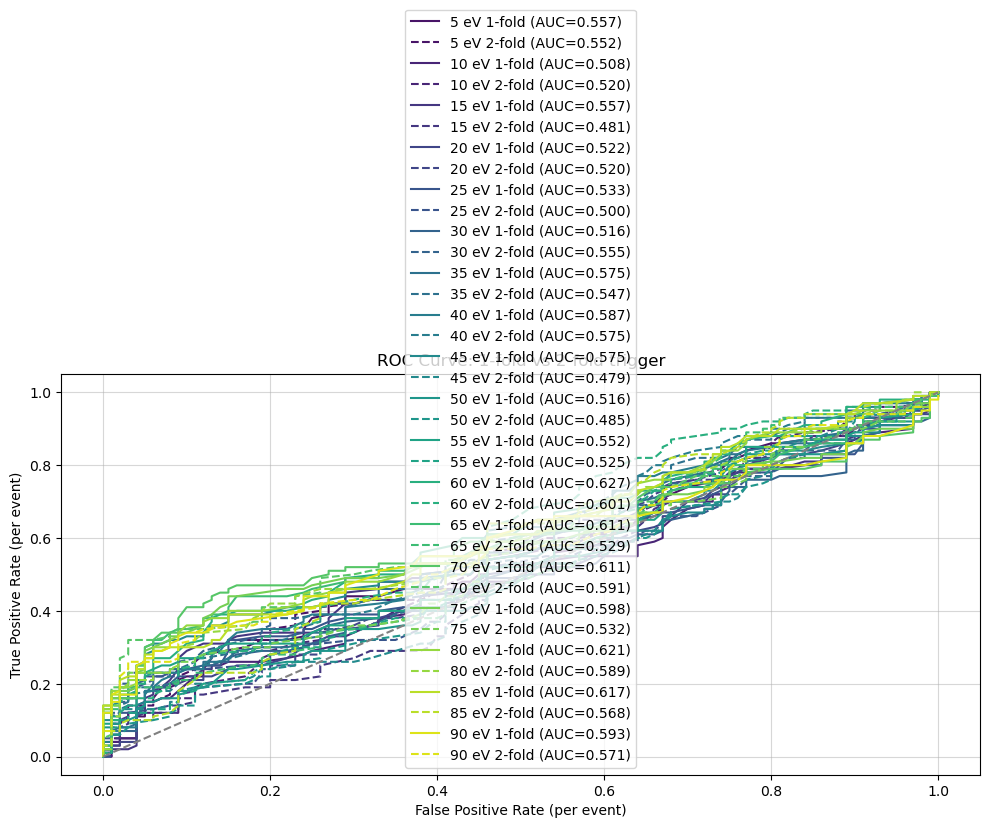

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# Assume all_amplitudes is already computed as shape (n_energies, n_sets, n_channels)
# energy_values is the list of energies used

thresholds = np.linspace(0, 6, 500)
n_energies = len(energy_values)

plt.figure(figsize=(10, 7))

# Index of noise energy
noise_idx = energy_values.index(0)
noise_ampls = all_amplitudes[noise_idx]  # shape (100, 9)

for e_idx, energy in enumerate(energy_values):
    if energy == 0:
        continue  # skip noise in signal loop
    sig_ampls = all_amplitudes[e_idx]  # shape (100, 9)

    tpr_1fold, fpr_1fold = [], []
    tpr_2fold, fpr_2fold = [], []

    for th in thresholds:
        # --- One-fold: pass if >=1 channel exceeds threshold ---
        sig_pass_1 = np.sum(sig_ampls > th, axis=1) >= 1
        noise_pass_1 = np.sum(noise_ampls > th, axis=1) >= 1
        tpr_1fold.append(sig_pass_1.mean())
        fpr_1fold.append(noise_pass_1.mean())

        # --- Two-fold: pass if >=2 channels exceed threshold ---
        sig_pass_2 = np.sum(sig_ampls > th, axis=1) >= 2
        noise_pass_2 = np.sum(noise_ampls > th, axis=1) >= 2
        tpr_2fold.append(sig_pass_2.mean())
        fpr_2fold.append(noise_pass_2.mean())

    # Compute AUC for info
    auc_1 = auc(fpr_1fold, tpr_1fold)
    auc_2 = auc(fpr_2fold, tpr_2fold)

    # Plot
    color = plt.cm.viridis(e_idx / n_energies)  # consistent color for both folds
    plt.plot(fpr_1fold, tpr_1fold, color=color, label=f"{energy} eV 1-fold (AUC={auc_1:.3f})")
    plt.plot(fpr_2fold, tpr_2fold, linestyle='--', color=color, label=f"{energy} eV 2-fold (AUC={auc_2:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate (per event)")
plt.ylabel("True Positive Rate (per event)")
plt.title("ROC Curve: 1-fold vs 2-fold trigger")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Processing energy 0 eV...
Processing energy 5 eV...
Processing energy 10 eV...
Processing energy 15 eV...
Processing energy 20 eV...
Processing energy 25 eV...
Processing energy 30 eV...
Processing energy 35 eV...
Processing energy 40 eV...
Processing energy 45 eV...
Processing energy 50 eV...
Processing energy 55 eV...
Processing energy 60 eV...
Processing energy 65 eV...
Processing energy 70 eV...
Processing energy 75 eV...
Processing energy 80 eV...
Processing energy 85 eV...
Processing energy 90 eV...
Processing energy 95 eV...
Done.
Result arrays:
  all_amplitudes: (20, 100, 9)
  valley_indices: (20, 100, 9)

Valley index stats across all energies/sets/channels:
  count: 18000
  min: 0
  max: 217232
  mean: 108661.76483333333
  std: 70645.03436872165

Per-channel valley index mean ± std:
  ch 00: 108797.8 ± 71460.5  (min=0, max=217232)
  ch 01: 110085.2 ± 71416.9  (min=0, max=217230)
  ch 02: 106113.0 ± 71941.9  (min=0, max=217230)
  ch 03: 110113.8 ± 69812.9  (min=0, max=217232)


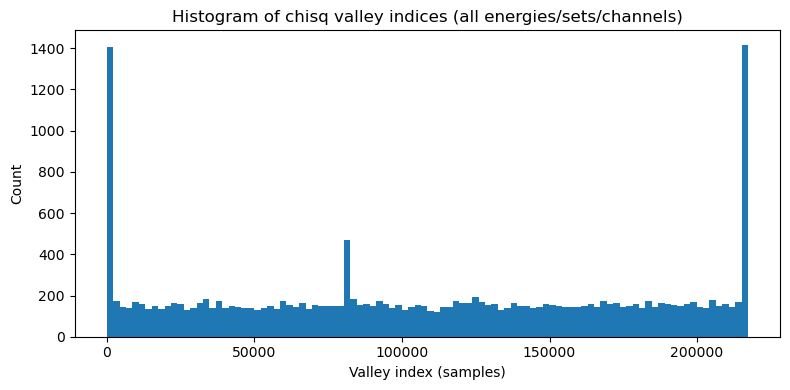

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from trace_IO import *

def deepest_valley_idx(chisq: np.ndarray, win: int = 4097) -> int:
    """
    Return index of the dominant local minimum ("big drop") in chisq.
    Uses a wide moving-average baseline via cumulative sums (fast, no SciPy).

    win: baseline window (must be odd). Choose >> dip width (e.g., 2049–8193).
    """
    y = np.asarray(chisq, dtype=float)
    if y.ndim != 1:
        raise ValueError("deepest_valley_idx expects a 1D array")
    win = int(win) | 1  # force odd >=1
    win = max(1, min(win, len(y) // 2 * 2 + 1))  # clamp to valid odd ≤ len(y)
    if win < 3:
        # fall back to trivial argmin if the window is too small
        return int(np.argmin(y))

    # moving average via cumulative sum (valid region)
    c = np.cumsum(np.insert(y, 0, 0.0))
    ma_valid = (c[win:] - c[:-win]) / win

    # pad to 'same' length by extending edges
    pad = win // 2
    baseline = np.pad(ma_valid, (pad, pad), mode='edge')

    drop = baseline - y
    # if NaNs present, treat them as -inf so they don't win
    if np.isnan(drop).any():
        drop = np.where(np.isnan(drop), -np.inf, drop)
    return int(np.argmax(drop))


def deepest_valley_indices_batch(chisq_arr: np.ndarray, win: int = 4097) -> np.ndarray:
    """
    Vectorized wrapper over first two dims.
    Input: chisq_arr shape (n_sets, n_channels, n_samples)
    Output: indices shape (n_sets, n_channels)
    """
    n_sets, n_channels, _ = chisq_arr.shape
    out = np.empty((n_sets, n_channels), dtype=np.int64)
    for i in range(n_sets):
        for j in range(n_channels):
            out[i, j] = deepest_valley_idx(chisq_arr[i, j], win=win)
    return out


# ---------------- Parameters ----------------
energy_values = list(range(0, 96, 5))  # e.g., 0, 5, 10, ..., 95
n_sets = 100
n_channels = 9
# n_samples is only used for sanity checks; not required a priori

# Outputs
all_amplitudes = np.empty((len(energy_values), n_sets, n_channels), dtype=float)
valley_indices = np.empty((len(energy_values), n_sets, n_channels), dtype=np.int64)

# ---------------- Main loop ----------------
for e_idx, energy in enumerate(energy_values):
    print(f"Processing energy {energy} eV...")

    # Load chisq and amplitude traces (expected shape: (n_sets, n_channels, n_samples))
    chisq_arr = load_ampl_from_zstd(
        f"/ceph/dwong/trigger_samples/lts_stft/chisq_energy_{energy}.zst",
        n_traces=n_sets
    )
    ampl_arr  = load_ampl_from_zstd(
        f"/ceph/dwong/trigger_samples/lts_stft/ampl_energy_{energy}.zst",
        n_traces=n_sets
    )

    if chisq_arr.shape[:2] != (n_sets, n_channels):
        raise ValueError(f"Unexpected chisq shape {chisq_arr.shape}, expected ({n_sets}, {n_channels}, n_samples)")
    if ampl_arr.shape != chisq_arr.shape:
        raise ValueError(f"ampl_arr shape {ampl_arr.shape} must match chisq_arr shape {chisq_arr.shape}")

    # Compute all valley indices for this energy in batch
    v_idx = deepest_valley_indices_batch(chisq_arr, win=4097)
    valley_indices[e_idx] = v_idx

    # Gather amplitudes at the valley indices
    # Use advanced indexing to avoid Python loops
    rows = np.arange(n_sets)[:, None]                  # (n_sets, 1)
    cols = np.arange(n_channels)[None, :]              # (1, n_channels)
    all_amplitudes[e_idx] = ampl_arr[rows, cols, v_idx]

print("Done.")
print("Result arrays:")
print("  all_amplitudes:", all_amplitudes.shape)  # (n_energies, n_sets, n_channels)
print("  valley_indices:", valley_indices.shape)  # (n_energies, n_sets, n_channels)

# ---------------- Sanity checks on valley indices ----------------
# Overall stats
flat_idx = valley_indices.ravel()
print("\nValley index stats across all energies/sets/channels:")
print("  count:", flat_idx.size)
print("  min:", int(np.min(flat_idx)))
print("  max:", int(np.max(flat_idx)))
print("  mean:", float(np.mean(flat_idx)))
print("  std:", float(np.std(flat_idx)))

# Per-channel stats (aggregated over energies and sets)
print("\nPer-channel valley index mean ± std:")
for ch in range(n_channels):
    ch_vals = valley_indices[:, :, ch].ravel()
    print(f"  ch {ch:02d}: {np.mean(ch_vals):.1f} ± {np.std(ch_vals):.1f}  "
          f"(min={np.min(ch_vals)}, max={np.max(ch_vals)})")

# ---------------- Histograms ----------------
# 1) Overall histogram (all energies/sets/channels)
plt.figure(figsize=(8, 4))
plt.hist(flat_idx, bins=100, edgecolor='none')
plt.xlabel("Valley index (samples)")
plt.ylabel("Count")
plt.title("Histogram of chisq valley indices (all energies/sets/channels)")
plt.tight_layout()
plt.show()

# 2) Optional: per-channel histogram grid (comment out if not needed)
#    Note: Creating many subplots can be slow; keep bins moderate.
# import math
# ncols = 3
# nrows = math.ceil(n_channels / ncols)
# fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
# axes = np.atleast_1d(axes).ravel()
# for ch in range(n_channels):
#     ax = axes[ch]
#     ax.hist(valley_indices[:, :, ch].ravel(), bins=80, edgecolor='none')
#     ax.set_title(f"Channel {ch}")
#     ax.set_xlabel("Valley index")
#     ax.set_ylabel("Count")
# for k in range(n_channels, len(axes)):
#     axes[k].axis('off')
# fig.suptitle("Per-channel chisq valley index histograms", y=1.02)
# fig.tight_layout()
# plt.show()

# 3) Optional: per-energy histogram overlay (commented; can be noisy)
# for e_idx, energy in enumerate(energy_values):
#     plt.figure(figsize=(7, 3.5))
#     plt.hist(valley_indices[e_idx].ravel(), bins=80, alpha=0.7, edgecolor='none')
#     plt.xlabel("Valley index (samples)")
#     plt.ylabel("Count")
#     plt.title(f"Histogram of valley indices @ {energy} eV")
#     plt.tight_layout()
#     plt.show()


Processing energy 0 eV...
Processing energy 5 eV...
Processing energy 10 eV...
Processing energy 15 eV...
Processing energy 20 eV...
Processing energy 25 eV...
Processing energy 30 eV...
Processing energy 35 eV...
Processing energy 40 eV...
Processing energy 45 eV...
Processing energy 50 eV...
Processing energy 55 eV...
Processing energy 60 eV...
Processing energy 65 eV...
Processing energy 70 eV...
Processing energy 75 eV...
Processing energy 80 eV...
Processing energy 85 eV...
Processing energy 90 eV...
Processing energy 95 eV...
Done.
Result arrays:
  all_amplitudes: (20, 100, 9)
  valley_indices: (20, 100, 9)


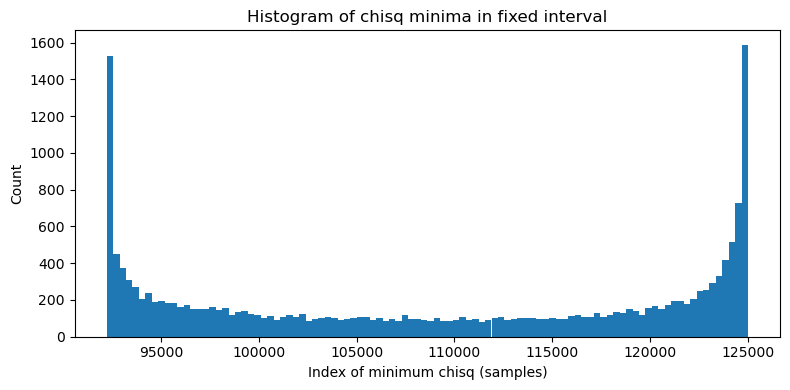

In [5]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from trace_IO import *

# Fixed search interval
CHEAT_START = 92232
CHEAT_LEN   = 32_768

# ---------------- Parameters ----------------
energy_values = list(range(0, 96, 5))
n_sets = 100
n_channels = 9

# Outputs
all_amplitudes = np.empty((len(energy_values), n_sets, n_channels), dtype=float)
valley_indices = np.empty((len(energy_values), n_sets, n_channels), dtype=np.int64)

# ---------------- Main loop ----------------
for e_idx, energy in enumerate(energy_values):
    print(f"Processing energy {energy} eV...")

    chisq_arr = load_ampl_from_zstd(
        f"/ceph/dwong/trigger_samples/lts_stft/chisq_energy_{energy}.zst",
        n_traces=n_sets
    )
    ampl_arr = load_ampl_from_zstd(
        f"/ceph/dwong/trigger_samples/lts_stft/ampl_energy_{energy}.zst",
        n_traces=n_sets
    )

    if chisq_arr.shape != ampl_arr.shape:
        raise ValueError(f"Shape mismatch: chisq {chisq_arr.shape}, ampl {ampl_arr.shape}")

    start = CHEAT_START
    stop = CHEAT_START + CHEAT_LEN

    for evt_idx in range(n_sets):
        for ch_idx in range(n_channels):
            # Find min chisq in the interval
            interval_chisq = chisq_arr[evt_idx, ch_idx, start:stop]
            local_idx = np.argmin(interval_chisq)  # index within interval
            global_idx = start + local_idx

            valley_indices[e_idx, evt_idx, ch_idx] = global_idx
            all_amplitudes[e_idx, evt_idx, ch_idx] = ampl_arr[evt_idx, ch_idx, global_idx]

print("Done.")
print("Result arrays:")
print("  all_amplitudes:", all_amplitudes.shape)
print("  valley_indices:", valley_indices.shape)

# ---------------- Histogram ----------------
flat_idx = valley_indices.ravel()
plt.figure(figsize=(8, 4))
plt.hist(flat_idx, bins=100, edgecolor='none')
plt.xlabel("Index of minimum chisq (samples)")
plt.ylabel("Count")
plt.title("Histogram of chisq minima in fixed interval")
plt.tight_layout()
plt.show()
